---
# Week 1 — Project Setup & Dataset Understanding


In [4]:
# Week 1 needs only pandas, numpy, matplotlib, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [6]:
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')

print('Dataset loaded!')
print(f'Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()


Dataset loaded!
Shape: 1300 rows, 6 columns


,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


### Step 3: Column Names and Data Types


In [8]:
print('Column names and their data types:')
print(df.dtypes)


Column names and their data types:
magnitude    float64
depth        float64
cdi          float64
mmi          float64
sig          float64
alert         object
dtype: object


### Step 4: Check for Missing Values and Duplicates


In [10]:
print('Missing values per column:')
print(df.isnull().sum())

print(f'\nDuplicate rows: {df.duplicated().sum()}')


Missing values per column:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

Duplicate rows: 44


### Step 5: Basic Statistics


In [12]:
df.describe().round(2)


,magnitude,depth,cdi,mmi,sig
count,1300.00,1300.00,1300.00,1300.00,1300.00
mean,7.06,50.32,6.98,6.94,-9.75
std,0.42,104.35,2.24,1.35,62.25
min,6.50,2.00,0.00,1.00,-128.00
25%,6.70,12.00,6.00,6.00,-54.00
50%,7.00,19.00,8.00,7.00,-7.00
75%,7.30,38.00,8.00,8.00,31.00
max,8.60,670.00,9.00,9.00,127.00


### Step 6: How Many Earthquakes in Each Alert Category?
The target column is `alert` — it has 4 classes: green, yellow, orange, red.


Count of each alert level:
alert
green     325
yellow    325
orange    325
red       325
Name: count, dtype: int64


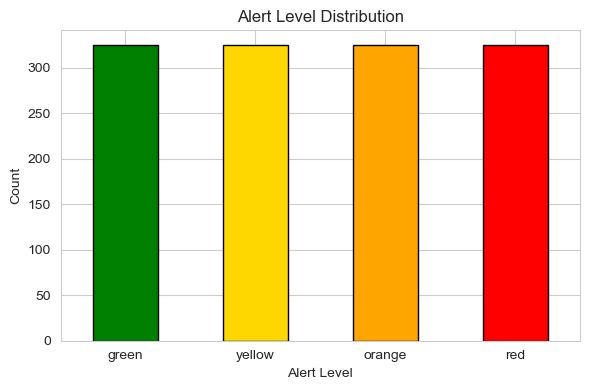

In [14]:
print('Count of each alert level:')
print(df['alert'].value_counts())

# Bar chart
color_map = {'green': 'green', 'yellow': 'gold', 'orange': 'orange', 'red': 'red'}
counts = df['alert'].value_counts()
colors = [color_map[c] for c in counts.index]

plt.figure(figsize=(6, 4))
counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Alert Level Distribution')
plt.xlabel('Alert Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Step 7: Histogram — Distribution of Each Feature


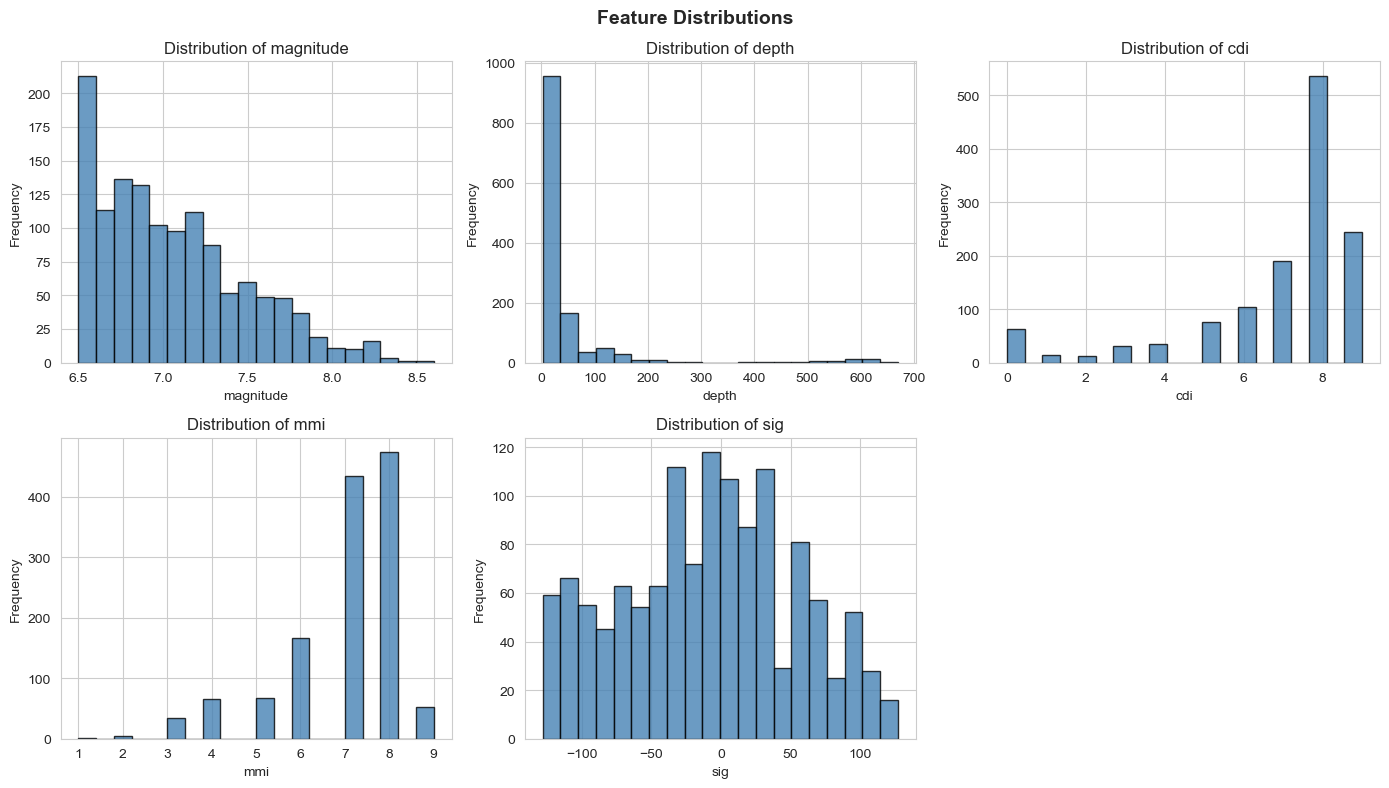

In [16]:
numeric_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 8: Boxplot — Feature vs Alert Level


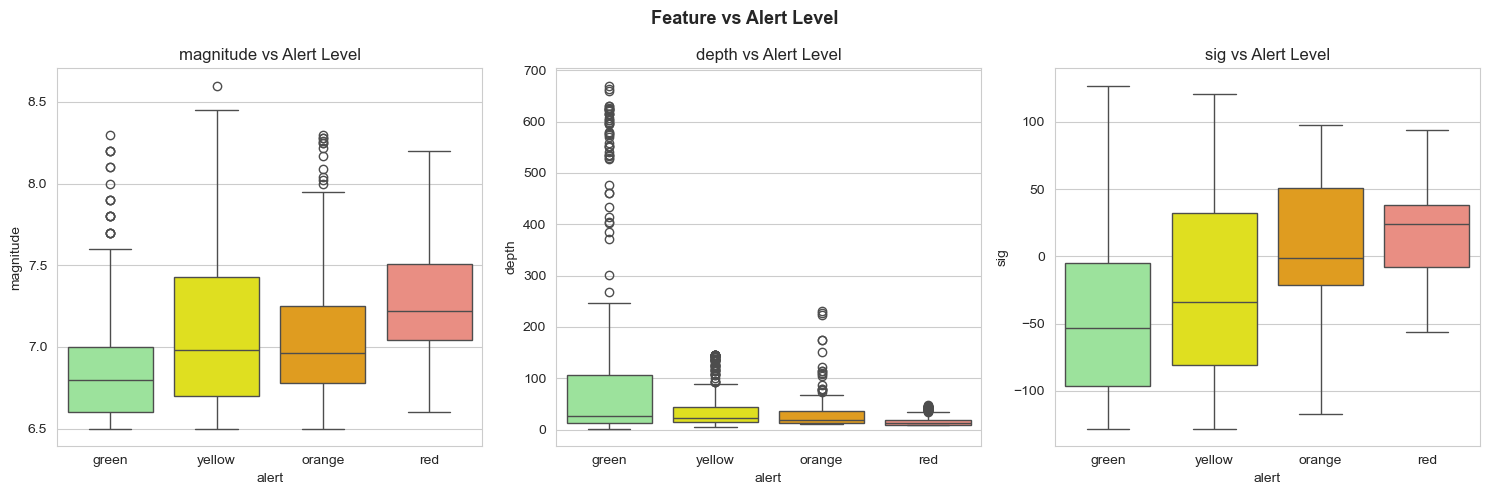

In [18]:
alert_order = ['green', 'yellow', 'orange', 'red']
palette = {'green': 'lightgreen', 'yellow': 'yellow', 'orange': 'orange', 'red': 'salmon'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['magnitude', 'depth', 'sig']):
    sns.boxplot(data=df, x='alert', y=col, order=alert_order, palette=palette, ax=ax)
    ax.set_title(f'{col} vs Alert Level')

plt.suptitle('Feature vs Alert Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 9: Correlation Heatmap


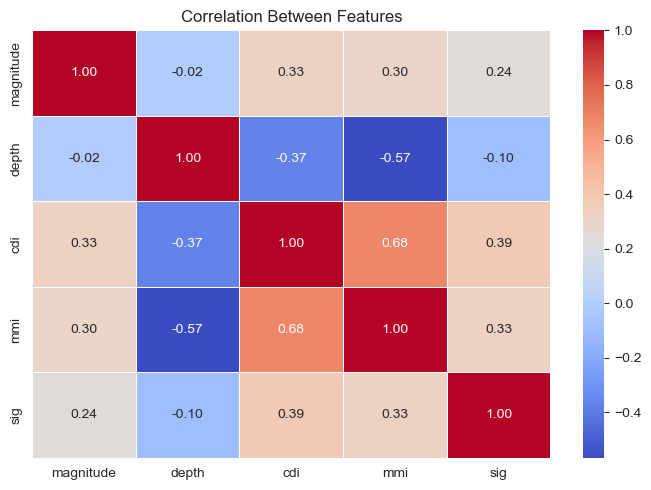

In [20]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Features')
plt.tight_layout()
plt.show()


---
# Week 2 — Preprocessing & Feature Engineering


### Step 1: Import Libraries for Week 2


In [23]:
# Week 2 adds sklearn preprocessing tools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


### Step 2: Remove Duplicates and Fill Missing Values


In [25]:
rows_before = len(df)

# Remove duplicates
df = df.drop_duplicates()

# Fill missing numeric values with median
for col in ['magnitude', 'depth', 'cdi', 'mmi', 'sig']:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print(f'Rows before: {rows_before}')
print(f'Rows after : {len(df)}')
print('Data is clean ✅')


Rows before: 1300
Rows after : 1256
Data is clean ✅


### Step 3: Label Encode the Target Column
We convert alert text to numbers so the model can understand it.


In [27]:
alert_mapping = {'green': 0, 'yellow': 1, 'orange': 2, 'red': 3}

df['alert_encoded'] = df['alert'].map(alert_mapping)

print('Mapping used:')
print(alert_mapping)

df[['alert', 'alert_encoded']].head(5)


Mapping used:
{'green': 0, 'yellow': 1, 'orange': 2, 'red': 3}


,alert,alert_encoded
0,green,0
1,green,0
2,green,0
3,green,0
4,green,0


### Step 4: Create New Features (Feature Engineering)
We add new columns that may help the model detect patterns better.


In [29]:
# 1. Is the earthquake shallow? (shallow = depth < 70 km, more damaging)
df['is_shallow'] = (df['depth'] < 70).astype(int)

# 2. Average of felt intensity (CDI) and instrumental intensity (MMI)
df['intensity_score'] = (df['cdi'] + df['mmi']) / 2

# 3. Combine magnitude and intensity into a single risk indicator
df['risk_score'] = df['magnitude'] * df['intensity_score']

print('New features created:')
print('  is_shallow      — 1 if depth < 70 km, else 0')
print('  intensity_score — average of cdi and mmi')
print('  risk_score      — magnitude x intensity_score')

df[['magnitude', 'depth', 'is_shallow', 'intensity_score', 'risk_score', 'alert']].head(5)


New features created:
  is_shallow      — 1 if depth < 70 km, else 0
  intensity_score — average of cdi and mmi
  risk_score      — magnitude x intensity_score


,magnitude,depth,is_shallow,intensity_score,risk_score,alert
0,7.0,14.0,1,7.5,52.5,green
1,6.9,25.0,1,4.0,27.6,green
2,7.0,579.0,0,3.0,21.0,green
3,7.3,37.0,1,5.0,36.5,green
4,6.6,624.0,0,1.0,6.6,green


### Step 5: Scale the Features
StandardScaler brings all features to the same range (mean=0, std=1).
This stops large-valued features (like depth) from dominating the model.


In [31]:
feature_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig',
                'is_shallow', 'intensity_score', 'risk_score']

X = df[feature_cols].copy()
y = df['alert_encoded'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features scaled ✅')
print(f'X shape: {X_scaled.shape}')
print(f'y shape: {y.shape}')


Features scaled ✅
X shape: (1256, 8)
y shape: (1256,)


### Step 6: Split into Training and Testing Sets
80% of data is used to train the model, 20% is held back to test it.


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # keeps class proportions the same in both sets
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')


Training samples : 1004
Testing samples  : 252


---
# Week 3 — Baseline Model Training


### Step 1: Import Libraries for Week 3


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print('Libraries loaded for Week 3 ✅')


Libraries loaded for Week 3 ✅


### Step 2: Helper Function — Evaluate Any Model
We write this once and reuse it for every model we train.


In [38]:
results = {}   # we will store model accuracies here for comparison

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    results[model_name] = round(acc * 100, 2)

    print(f'Model   : {model_name}')
    print(f'Accuracy: {acc * 100:.2f}%')
    print()

    label_names = ['green', 'yellow', 'orange', 'red']
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()


### Step 3: Model 1 — Logistic Regression
A simple linear model that finds the best boundary to separate classes.


Model   : Logistic Regression
Accuracy: 59.13%

              precision    recall  f1-score   support

       green       0.84      0.78      0.81        65
      yellow       0.47      0.56      0.51        64
      orange       0.40      0.33      0.36        63
         red       0.67      0.68      0.68        60

    accuracy                           0.59       252
   macro avg       0.59      0.59      0.59       252
weighted avg       0.59      0.59      0.59       252



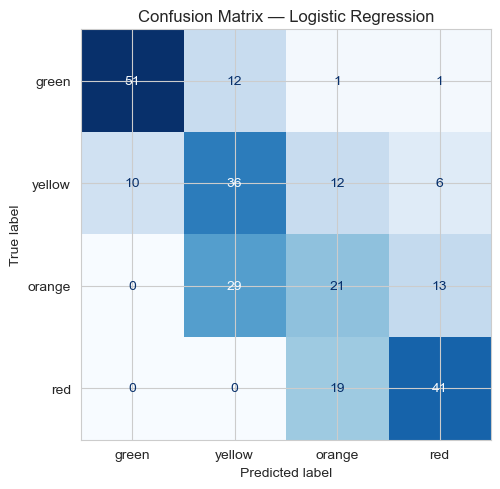

In [40]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

evaluate_model('Logistic Regression', y_test, lr_preds)


### Step 4: Model 2 — Decision Tree
A tree-based model that asks yes/no questions to classify each earthquake.
Example: Is magnitude > 7.2? Is depth < 30?


Model   : Decision Tree
Accuracy: 78.57%

              precision    recall  f1-score   support

       green       0.98      0.80      0.88        65
      yellow       0.74      0.75      0.74        64
      orange       0.71      0.70      0.70        63
         red       0.75      0.90      0.82        60

    accuracy                           0.79       252
   macro avg       0.79      0.79      0.79       252
weighted avg       0.80      0.79      0.79       252



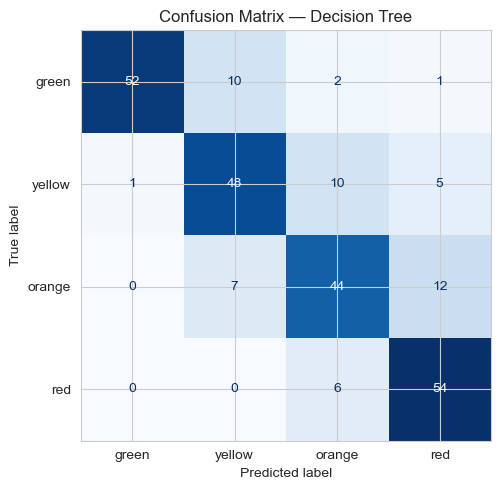

In [42]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

evaluate_model('Decision Tree', y_test, dt_preds)


### Step 5: Feature Importance (from Decision Tree)


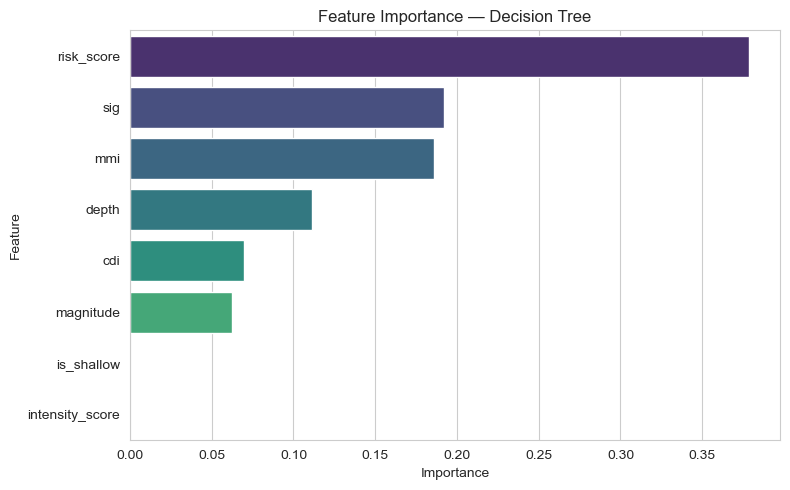

        Feature  Importance
     risk_score    0.378675
            sig    0.192098
            mmi    0.185840
          depth    0.111557
            cdi    0.069615
      magnitude    0.062215
     is_shallow    0.000000
intensity_score    0.000000


In [44]:
feature_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig',
                'is_shallow', 'intensity_score', 'risk_score']

feat_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Decision Tree')
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))


### Step 6: Compare Both Models


Model Accuracy Comparison:
              Model  Accuracy
Logistic Regression     59.13
      Decision Tree     78.57


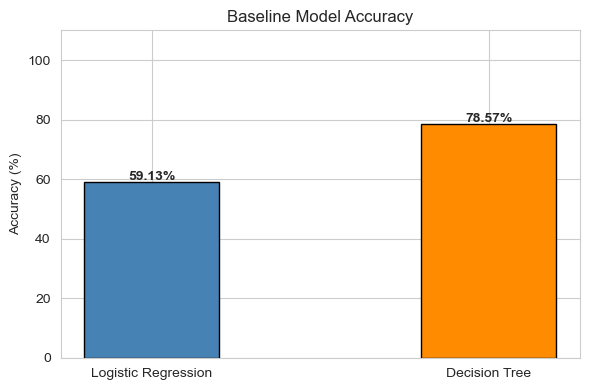

In [46]:
compare_df = pd.DataFrame({
    'Model'   : list(results.keys()),
    'Accuracy': list(results.values())
})

print('Model Accuracy Comparison:')
print(compare_df.to_string(index=False))

plt.figure(figsize=(6, 4))
bars = plt.bar(compare_df['Model'], compare_df['Accuracy'],
               color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)

for bar, val in zip(bars, compare_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', fontweight='bold')

plt.ylim(0, 110)
plt.title('Baseline Model Accuracy')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()
